# Side-Channel Attack Detection Pipeline

This notebook builds a complete training and evaluation workflow for detecting cache-based covert-channel activity from Linux `perf` hardware performance counter traces.

It covers:

- Hybrid ingestion for Ubuntu-style and Fedora-style `perf stat` outputs
- Preprocessing and normalization
- Exploratory Data Analysis (EDA)
- Feature engineering
- Separate model training for Ubuntu and Fedora
- Model comparison using `Random Forest`, `SVM`, and `CNN-LSTM`
- Cross-OS generalization experiments
- Saving every important plot and table into `results/` for report and presentation reuse

Assumptions:

- The notebook is run from the project root on the EC2 instance
- The raw files live in either `dataset/` or `data/`
- Labels are derived from file names: `benign` -> `0`, `attack` -> `1`
- You already created a top-level `results/` directory on the EC2 instance

## 1. Environment Setup

If your EC2 notebook environment is missing dependencies, run the next cell once.

In [1]:
# Uncomment this cell if packages are missing in your EC2 notebook environment.
# %pip install -q numpy pandas matplotlib seaborn scikit-learn joblib tensorflow

## 2. Imports

The notebook is intentionally commented in a project-friendly style so that it can be reused during report writing,
presentation preparation, and final deployment.

In [2]:
from __future__ import annotations

import json
import math
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import LSTM, BatchNormalization, Conv1D, Dense, Dropout, MaxPooling1D

    TF_AVAILABLE = True
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = exc

I0000 00:00:1777326519.036903    1009 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777326520.628141    1009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777326524.783509    1009 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Paths and Project Configuration

This path resolver makes the notebook portable between your local copy and the EC2 instance.
It also ensures that all figures and summary CSV files are saved into `results/`, while trained models are saved into `artifacts/`.

In [3]:
RANDOM_STATE = 42
RAW_EVENTS = [
    "cache_misses",
    "cache_references",
    "instructions",
    "cycles",
    "branches",
    "branch_misses",
]
RATIO_FEATURES = [
    "ipc",
    "cpi",
    "cache_miss_rate",
    "branch_miss_rate",
    "cache_misses_per_kinst",
    "cache_references_per_kinst",
    "branches_per_kinst",
    "cycles_per_branch",
]


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "dataset").exists() or (candidate / "data").exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "dataset" if (PROJECT_ROOT / "dataset").exists() else PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

FILE_MAP = {
    "ubuntu": {
        "benign": DATA_DIR / "benign_data.csv",
        "attack": DATA_DIR / "attack_data_final.csv",
    },
    "fedora": {
        "benign": DATA_DIR / "benign_fedora.csv",
        "attack": DATA_DIR / "attack_fedora.csv",
    },
}

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Artifacts directory:", ARTIFACTS_DIR)
print(json.dumps({k: {kk: str(vv) for kk, vv in v.items()} for k, v in FILE_MAP.items()}, indent=2))

Project root: /home/ubuntu/SideChannelAI
Data directory: /home/ubuntu/SideChannelAI/dataset
Results directory: /home/ubuntu/SideChannelAI/results
Artifacts directory: /home/ubuntu/SideChannelAI/artifacts
{
  "ubuntu": {
    "benign": "/home/ubuntu/SideChannelAI/dataset/benign_data.csv",
    "attack": "/home/ubuntu/SideChannelAI/dataset/attack_data_final.csv"
  },
  "fedora": {
    "benign": "/home/ubuntu/SideChannelAI/dataset/benign_fedora.csv",
    "attack": "/home/ubuntu/SideChannelAI/dataset/attack_fedora.csv"
  }
}


In [4]:
def slugify(text: str) -> str:
    """Create stable filenames for plots and exported tables."""
    return (
        text.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("->", "_to_")
        .replace("-", "_")
    )


def save_current_figure(filename: str, dpi: int = 180):
    """Save the currently active Matplotlib figure into the results directory."""
    output_path = RESULTS_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


def save_dataframe(df: pd.DataFrame, filename: str):
    """Save a DataFrame to CSV in the results directory for later report writing."""
    output_path = RESULTS_DIR / filename
    df.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")


def save_text(text: str, filename: str):
    """Persist plain-text reports such as classification reports."""
    output_path = RESULTS_DIR / filename
    output_path.write_text(text, encoding="utf-8")
    print(f"Saved text report: {output_path}")

## 3. Hybrid Ingestion Engine

Ubuntu and Fedora produced different `perf` formats. The parser below detects each line format and converts both into a single long-form schema before pivoting to one row per sampling timestamp.

In [5]:
UBUNTU_CSV_PATTERN = re.compile(r"^\s*\d")
FEDORA_PATTERN = re.compile(r"^\s*([0-9]+\.[0-9]+)\s+([0-9,]+)\s+([A-Za-z0-9\-]+)\s*$")


def safe_int(value: str) -> int | None:
    value = str(value).replace(",", "").strip()
    if value in {"", "<not", "<not counted>", "not", "not counted"}:
        return None
    try:
        return int(float(value))
    except ValueError:
        return None


def parse_perf_line(line: str):
    stripped = line.strip()
    if not stripped or stripped.startswith("#"):
        return None

    if "," in stripped:
        parts = [part.strip() for part in stripped.split(",")]
        if len(parts) >= 4:
            time_sec = float(parts[0])
            count = safe_int(parts[1])
            event = parts[3].replace("-", "_")
            return time_sec, event, count

    match = FEDORA_PATTERN.match(stripped)
    if match:
        time_sec = float(match.group(1))
        count = safe_int(match.group(2))
        event = match.group(3).replace("-", "_")
        return time_sec, event, count

    parts = re.split(r"\s+", stripped)
    if len(parts) >= 3:
        try:
            time_sec = float(parts[0])
            count = safe_int(parts[1])
            event = parts[-1].replace("-", "_")
            return time_sec, event, count
        except ValueError:
            return None

    return None


def load_perf_file(path: Path, label_name: str, os_name: str) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            parsed = parse_perf_line(line)
            if parsed is None:
                continue
            time_sec, event, count = parsed
            if event in RAW_EVENTS and count is not None:
                rows.append((time_sec, event, count))

    long_df = pd.DataFrame(rows, columns=["time_sec", "event", "count"])
    wide_df = (
        long_df.pivot_table(index="time_sec", columns="event", values="count", aggfunc="first")
        .reset_index()
        .sort_values("time_sec")
        .reset_index(drop=True)
    )
    wide_df.columns.name = None
    wide_df["label_name"] = label_name
    wide_df["label"] = 1 if label_name == "attack" else 0
    wide_df["os_name"] = os_name
    wide_df["source_file"] = path.name
    return wide_df


def load_os_dataset(os_name: str) -> pd.DataFrame:
    benign_df = load_perf_file(FILE_MAP[os_name]["benign"], "benign", os_name)
    attack_df = load_perf_file(FILE_MAP[os_name]["attack"], "attack", os_name)
    combined = pd.concat([benign_df, attack_df], ignore_index=True)
    combined = combined.sort_values(["label_name", "time_sec"]).reset_index(drop=True)
    return combined

In [6]:
ubuntu_raw = load_os_dataset("ubuntu")
fedora_raw = load_os_dataset("fedora")

display(ubuntu_raw.head())
display(fedora_raw.head())

print("Ubuntu shape:", ubuntu_raw.shape)
print("Fedora shape:", fedora_raw.shape)

,time_sec,branch_misses,branches,cache_misses,cache_references,cycles,instructions,label_name,label,os_name,source_file
0,0.050139,86319,794257,34766,1410428,13661294,4697109,attack,1,ubuntu,attack_data_final.csv
1,0.100872,82439,829753,30090,1290996,13136130,4840588,attack,1,ubuntu,attack_data_final.csv
2,0.151583,84852,760459,13179,1354729,13159304,4481040,attack,1,ubuntu,attack_data_final.csv
3,0.202306,85591,772078,9324,1375802,13268332,4544242,attack,1,ubuntu,attack_data_final.csv
4,0.253034,84250,773742,14595,1346688,13118809,4563988,attack,1,ubuntu,attack_data_final.csv


,time_sec,branch_misses,branches,cache_misses,cache_references,cycles,instructions,label_name,label,os_name,source_file
0,0.050146,19745,333119,15115,223986,4753477,1750676,attack,1,fedora,attack_fedora.csv
1,0.100383,12834,131291,209,151087,2769251,751024,attack,1,fedora,attack_fedora.csv
2,0.150600,12807,127943,153,150063,2737169,733611,attack,1,fedora,attack_fedora.csv
3,0.200815,12787,126588,202,149825,2719413,725739,attack,1,fedora,attack_fedora.csv
4,0.251042,10642,127864,169,133243,2659484,732297,attack,1,fedora,attack_fedora.csv


Ubuntu shape: (150519, 11)
Fedora shape: (59020, 11)


## 4. Data Quality Checks

In [7]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    # This report helps us verify that the ingestion step produced a clean,
    # fully numeric table before we start building ML features.
    report = pd.DataFrame(
        {
            "missing_values": df.isna().sum(),
            "dtype": df.dtypes.astype(str),
        }
    )
    print(f"\n{name} label counts")
    display(df["label_name"].value_counts())
    print(f"\n{name} missing values")
    display(report)
    return report


ubuntu_quality = quality_report(ubuntu_raw, "Ubuntu")
fedora_quality = quality_report(fedora_raw, "Fedora")

ubuntu_quality.reset_index().rename(columns={"index": "column"}).to_csv(RESULTS_DIR / "ubuntu_quality_report.csv", index=False)
fedora_quality.reset_index().rename(columns={"index": "column"}).to_csv(RESULTS_DIR / "fedora_quality_report.csv", index=False)


Ubuntu label counts


label_name
attack    77513
benign    73006
Name: count, dtype: int64


Ubuntu missing values


,missing_values,dtype
time_sec,0,float64
branch_misses,0,int64
branches,0,int64
cache_misses,0,int64
cache_references,0,int64
cycles,0,int64
instructions,0,int64
label_name,0,str
label,0,int64
os_name,0,str



Fedora label counts


label_name
benign    35783
attack    23237
Name: count, dtype: int64


Fedora missing values


,missing_values,dtype
time_sec,0,float64
branch_misses,0,int64
branches,0,int64
cache_misses,0,int64
cache_references,0,int64
cycles,0,int64
instructions,0,int64
label_name,0,str
label,0,int64
os_name,0,str


## 5. Preprocessing and Feature Engineering

The feature set includes:

- Raw counter values
- Microarchitectural ratios
- First-order temporal differences
- Short rolling statistics

In [8]:
def safe_divide(series_a: pd.Series, series_b: pd.Series) -> pd.Series:
    # We explicitly guard against division-by-zero because HPC counters can
    # occasionally produce empty or zero-valued intervals.
    result = series_a.astype(float) / series_b.replace(0, np.nan).astype(float)
    return result.replace([np.inf, -np.inf], np.nan)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    # Feature engineering is where raw HPC values become security-relevant
    # indicators. The ratios below capture behavioral shifts that are harder
    # to see from raw counts alone.
    df = df.copy().sort_values(["label_name", "time_sec"]).reset_index(drop=True)

    for col in RAW_EVENTS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ipc"] = safe_divide(df["instructions"], df["cycles"])
    df["cpi"] = safe_divide(df["cycles"], df["instructions"])
    df["cache_miss_rate"] = safe_divide(df["cache_misses"], df["cache_references"])
    df["branch_miss_rate"] = safe_divide(df["branch_misses"], df["branches"])
    df["cache_misses_per_kinst"] = safe_divide(df["cache_misses"] * 1000, df["instructions"])
    df["cache_references_per_kinst"] = safe_divide(df["cache_references"] * 1000, df["instructions"])
    df["branches_per_kinst"] = safe_divide(df["branches"] * 1000, df["instructions"])
    df["cycles_per_branch"] = safe_divide(df["cycles"], df["branches"])

    group_key = ["os_name", "label_name"]
    for col in RAW_EVENTS:
        df[f"{col}_diff"] = df.groupby(group_key)[col].diff().fillna(0)

    rolling_features = RAW_EVENTS + ["cache_miss_rate", "branch_miss_rate"]
    for col in rolling_features:
        df[f"{col}_roll_mean_5"] = (
            df.groupby(group_key)[col]
            .transform(lambda s: s.rolling(window=5, min_periods=1).mean())
        )
        df[f"{col}_roll_std_5"] = (
            df.groupby(group_key)[col]
            .transform(lambda s: s.rolling(window=5, min_periods=1).std())
            .fillna(0)
        )

    df = df.replace([np.inf, -np.inf], np.nan)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    return df


ubuntu_df = engineer_features(ubuntu_raw)
fedora_df = engineer_features(fedora_raw)

print("Ubuntu engineered shape:", ubuntu_df.shape)
print("Fedora engineered shape:", fedora_df.shape)
display(ubuntu_df.head())

Ubuntu engineered shape: (150519, 41)
Fedora engineered shape: (59020, 41)


,time_sec,branch_misses,branches,cache_misses,cache_references,cycles,instructions,label_name,label,os_name,source_file,ipc,cpi,cache_miss_rate,branch_miss_rate,cache_misses_per_kinst,cache_references_per_kinst,branches_per_kinst,cycles_per_branch,cache_misses_diff,cache_references_diff,instructions_diff,cycles_diff,branches_diff,branch_misses_diff,cache_misses_roll_mean_5,cache_misses_roll_std_5,cache_references_roll_mean_5,cache_references_roll_std_5,instructions_roll_mean_5,instructions_roll_std_5,cycles_roll_mean_5,cycles_roll_std_5,branches_roll_mean_5,branches_roll_std_5,branch_misses_roll_mean_5,branch_misses_roll_std_5,cache_miss_rate_roll_mean_5,cache_miss_rate_roll_std_5,branch_miss_rate_roll_mean_5,branch_miss_rate_roll_std_5
0,0.050139,86319,794257,34766,1410428,13661294,4697109,attack,1,ubuntu,attack_data_final.csv,0.343826,2.908447,0.024649,0.108679,7.401574,300.275765,169.094862,17.200093,0.0,0.0,0.0,0.0,0.0,0.0,34766.000000,0.000000,1410428.00,0.000000,4.697109e+06,0.000000,1.366129e+07,0.000000,794257.00,0.000000,86319.000000,0.000000,0.024649,0.000000,0.108679,0.000000
1,0.100872,82439,829753,30090,1290996,13136130,4840588,attack,1,ubuntu,attack_data_final.csv,0.368494,2.713747,0.023308,0.099354,6.216187,266.702310,171.415745,15.831374,-4676.0,-119432.0,143479.0,-525164.0,35496.0,-3880.0,32428.000000,3306.431309,1350712.00,84451.177091,4.768848e+06,101454.973858,1.339871e+07,371347.025635,812005.00,25099.462305,84379.000000,2743.574311,0.023978,0.000949,0.104016,0.006594
2,0.151583,84852,760459,13179,1354729,13159304,4481040,attack,1,ubuntu,attack_data_final.csv,0.340523,2.936663,0.009728,0.111580,2.941058,302.324684,169.705916,17.304423,-16911.0,63733.0,-359548.0,23174.0,-69294.0,2413.0,26011.666667,11356.682805,1352051.00,59761.019227,4.672912e+06,180991.160238,1.331891e+07,296740.127966,794823.00,34650.467183,84536.666667,1959.126421,0.019228,0.008255,0.106538,0.006388
3,0.202306,85591,772078,9324,1375802,13268332,4544242,attack,1,ubuntu,attack_data_final.csv,0.342488,2.919812,0.006777,0.110858,2.051827,302.757204,169.902483,17.185222,-3855.0,21073.0,63202.0,109028.0,11619.0,739.0,21839.750000,12474.068472,1357988.75,50218.991556,4.640745e+06,161175.516316,1.330626e+07,243603.473618,789136.75,30492.135712,84800.250000,1684.247285,0.016116,0.009175,0.107618,0.005646
4,0.253034,84250,773742,14595,1346688,13118809,4563988,attack,1,ubuntu,attack_data_final.csv,0.347897,2.874418,0.010838,0.108886,3.197861,295.068260,169.531997,16.955017,5271.0,-29114.0,19746.0,-149523.0,1664.0,-1341.0,20390.800000,11278.256457,1355728.60,43783.578255,4.625393e+06,143741.017211,1.326877e+07,227013.082566,786057.80,27289.694405,84690.200000,1479.213203,0.015060,0.008289,0.107871,0.004922


## 6. Exploratory Data Analysis

The following helpers keep visualizations readable for large datasets by sampling when needed.

In [9]:
def sampled(df: pd.DataFrame, n: int = 15000) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_STATE).sort_values("time_sec")


def run_eda(df: pd.DataFrame, os_name: str):
    sample_df = sampled(df, n=12000)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.countplot(data=df, x="label_name", ax=axes[0, 0], palette="Set2")
    axes[0, 0].set_title(f"{os_name.title()} label distribution")

    sns.boxplot(data=sample_df, x="label_name", y="cache_miss_rate", ax=axes[0, 1], palette="Set2")
    axes[0, 1].set_title(f"{os_name.title()} cache miss rate by class")

    sns.boxplot(data=sample_df, x="label_name", y="branch_miss_rate", ax=axes[1, 0], palette="Set2")
    axes[1, 0].set_title(f"{os_name.title()} branch miss rate by class")

    sns.boxplot(data=sample_df, x="label_name", y="ipc", ax=axes[1, 1], palette="Set2")
    axes[1, 1].set_title(f"{os_name.title()} IPC by class")

    plt.tight_layout()
    save_current_figure(f"{os_name}_eda_core_distributions.png")
    plt.show()

    timeline_cols = ["cache_misses", "cache_references", "cycles", "cache_miss_rate"]
    fig, axes = plt.subplots(len(timeline_cols), 1, figsize=(16, 12), sharex=True)
    for ax, col in zip(axes, timeline_cols):
        for label_name, subset in sample_df.groupby("label_name"):
            subset_sorted = subset.sort_values("time_sec")
            ax.plot(subset_sorted["time_sec"], subset_sorted[col], label=label_name, alpha=0.7)
        ax.set_title(f"{os_name.title()} timeline: {col}")
        ax.legend()
    plt.tight_layout()
    save_current_figure(f"{os_name}_eda_timelines.png")
    plt.show()

    corr_cols = RAW_EVENTS + RATIO_FEATURES
    corr = sample_df[corr_cols + ["label"]].corr(numeric_only=True)
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"{os_name.title()} feature correlation heatmap")
    save_current_figure(f"{os_name}_correlation_heatmap.png")
    plt.show()

    summary = (
        df.groupby("label_name")[RAW_EVENTS + RATIO_FEATURES]
        .agg(["mean", "median", "std"])
        .round(4)
    )
    display(summary)
    summary.to_csv(RESULTS_DIR / f"{os_name}_eda_summary_statistics.csv")

Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_eda_core_distributions.png


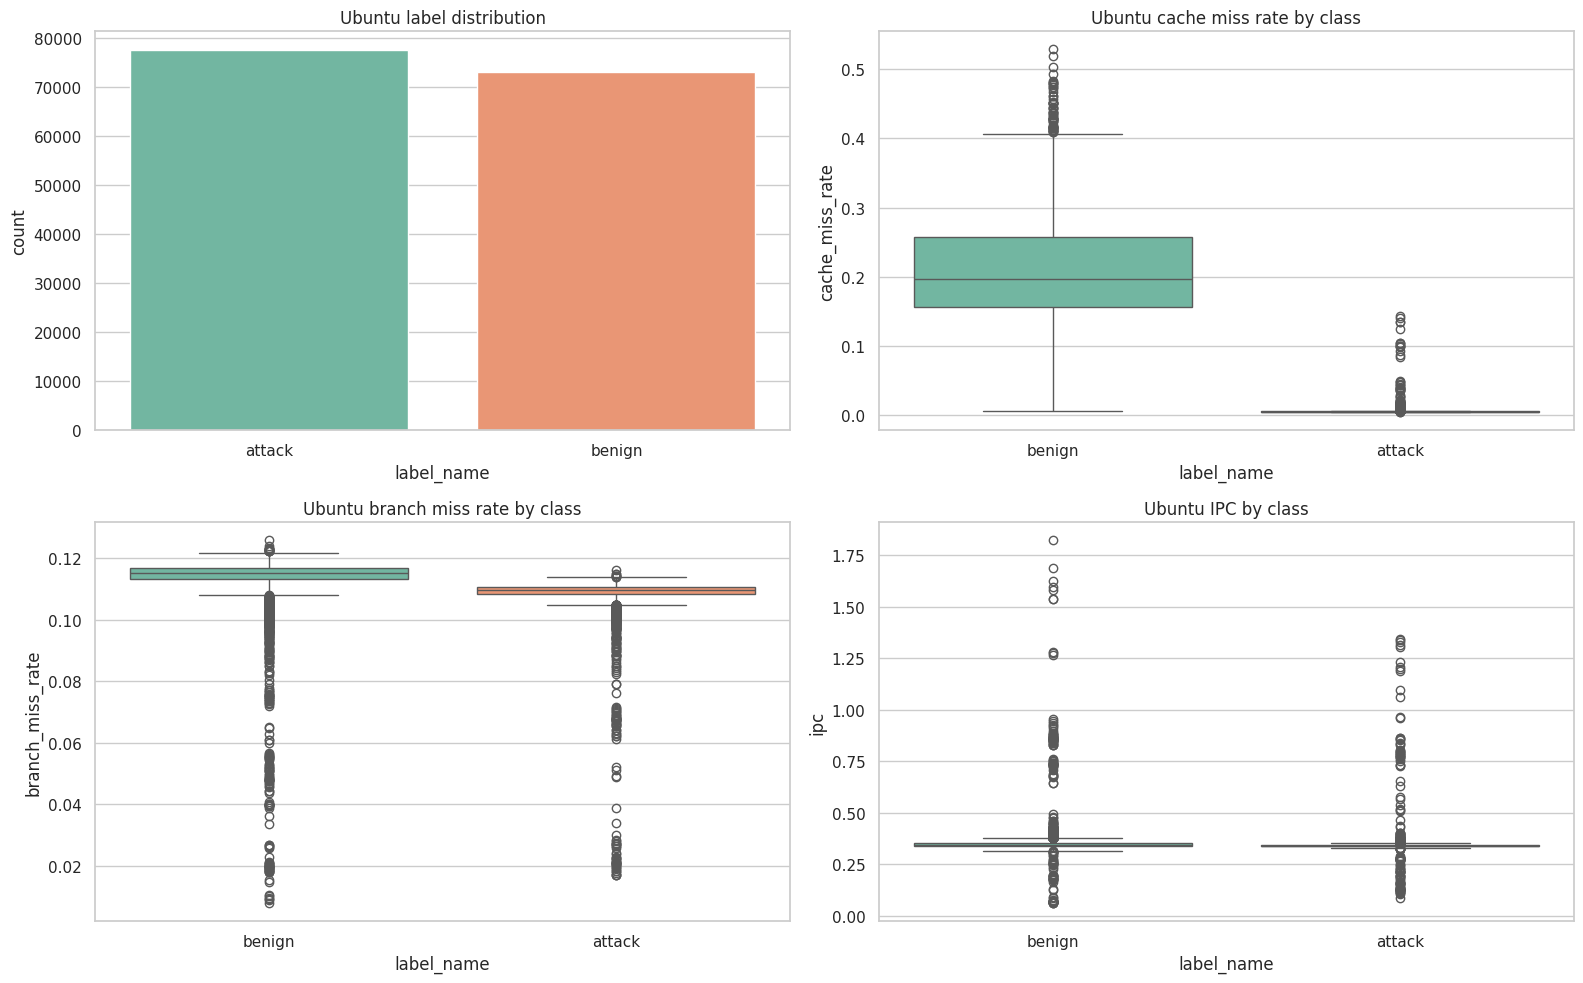

Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_eda_timelines.png


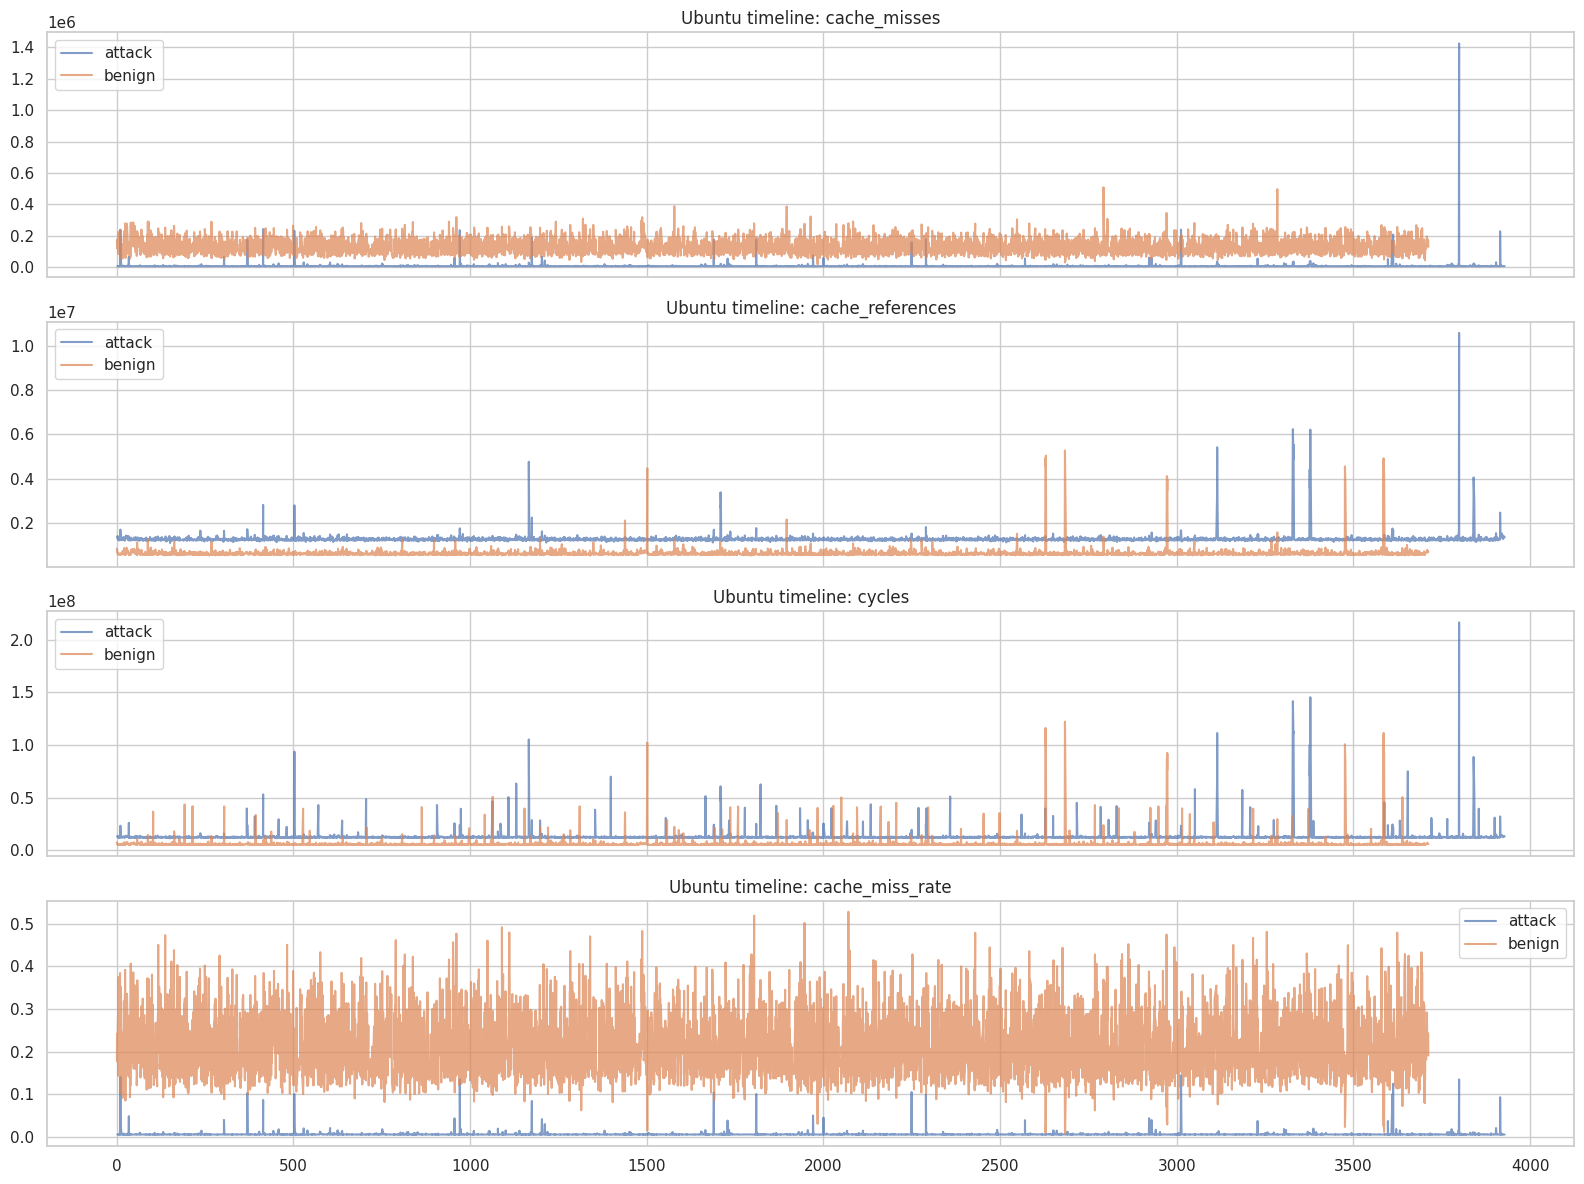

Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_correlation_heatmap.png


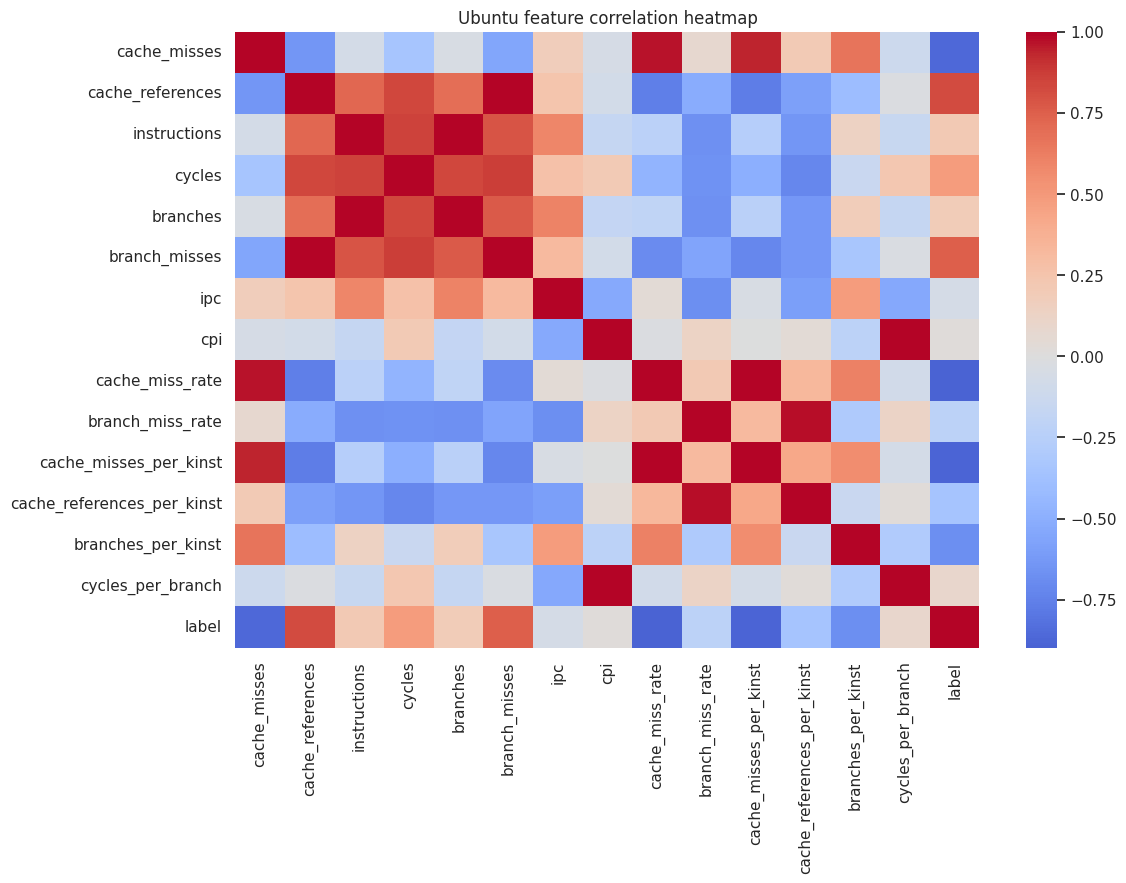

cache_misses                       cache_references             \
                   mean    median         std             mean     median   
label_name                                                                  
attack        7717.0892    6592.0  19493.5848     1.264191e+06  1240509.0   
benign      128758.4756  121067.0  45880.2660     6.240354e+05   589751.0   

                         instructions                                 cycles  \
                    std          mean     median           std          mean   
label_name                                                                     
attack      225175.4675  4.619443e+06  4145668.0  7.787804e+06  1.294283e+07   
benign      248958.0045  2.304795e+06  1811607.0  5.123232e+06  6.120969e+06   

                                         branches                          \
                median           std         mean    median           std   
label_name                                                                  
attack      12209380.0  6.418787e+06  799123.3973  703023.0  1.942459e+06   
benign       5290679.5  6.447184e+06  411610.8310  317910.0  9.706060e+05   

           branch_misses                          ipc                     cpi  \
                    mean   median         std    mean  median     std    mean   
label_name                                                                      
attack        78941.8878  77165.0  17585.8638  0.3436  0.3398  0.0568  2.9508   
benign        39242.5934  36703.0  17793.0763  0.3518  0.3445  0.0717  2.9299   

                           cache_miss_rate                 branch_miss_rate  \
            median     std            mean  median     std             mean   
label_name                                                                    
attack      2.9431  0.4161          0.0058  0.0053  0.0051           0.1082   
benign      2.9025  0.8860          0.2107  0.1957  0.0723           0.1127   

                           cache_misses_per_kinst                    \
            median     std                   mean   median      std   
label_name                                                            
attack      0.1096  0.0080                 1.6473   1.5857   0.4432   
benign      0.1153  0.0113                67.0416  62.3324  24.0207   

           cache_references_per_kinst                    branches_per_kinst  \
                                 mean    median      std               mean   
label_name                                                                    
attack                       295.0673  299.0113  22.7124           169.9111   
benign                       317.4234  325.6719  34.7092           175.9219   

                             cycles_per_branch                   
              median     std              mean   median     std  
label_name                                                       
attack      169.5988  2.9896           17.3811  17.3529  2.5018  
benign      175.4941  3.2946           16.6848  16.5328  5.2916

In [10]:
run_eda(ubuntu_df, "ubuntu")

Saved figure: /home/ubuntu/SideChannelAI/results/fedora_eda_core_distributions.png


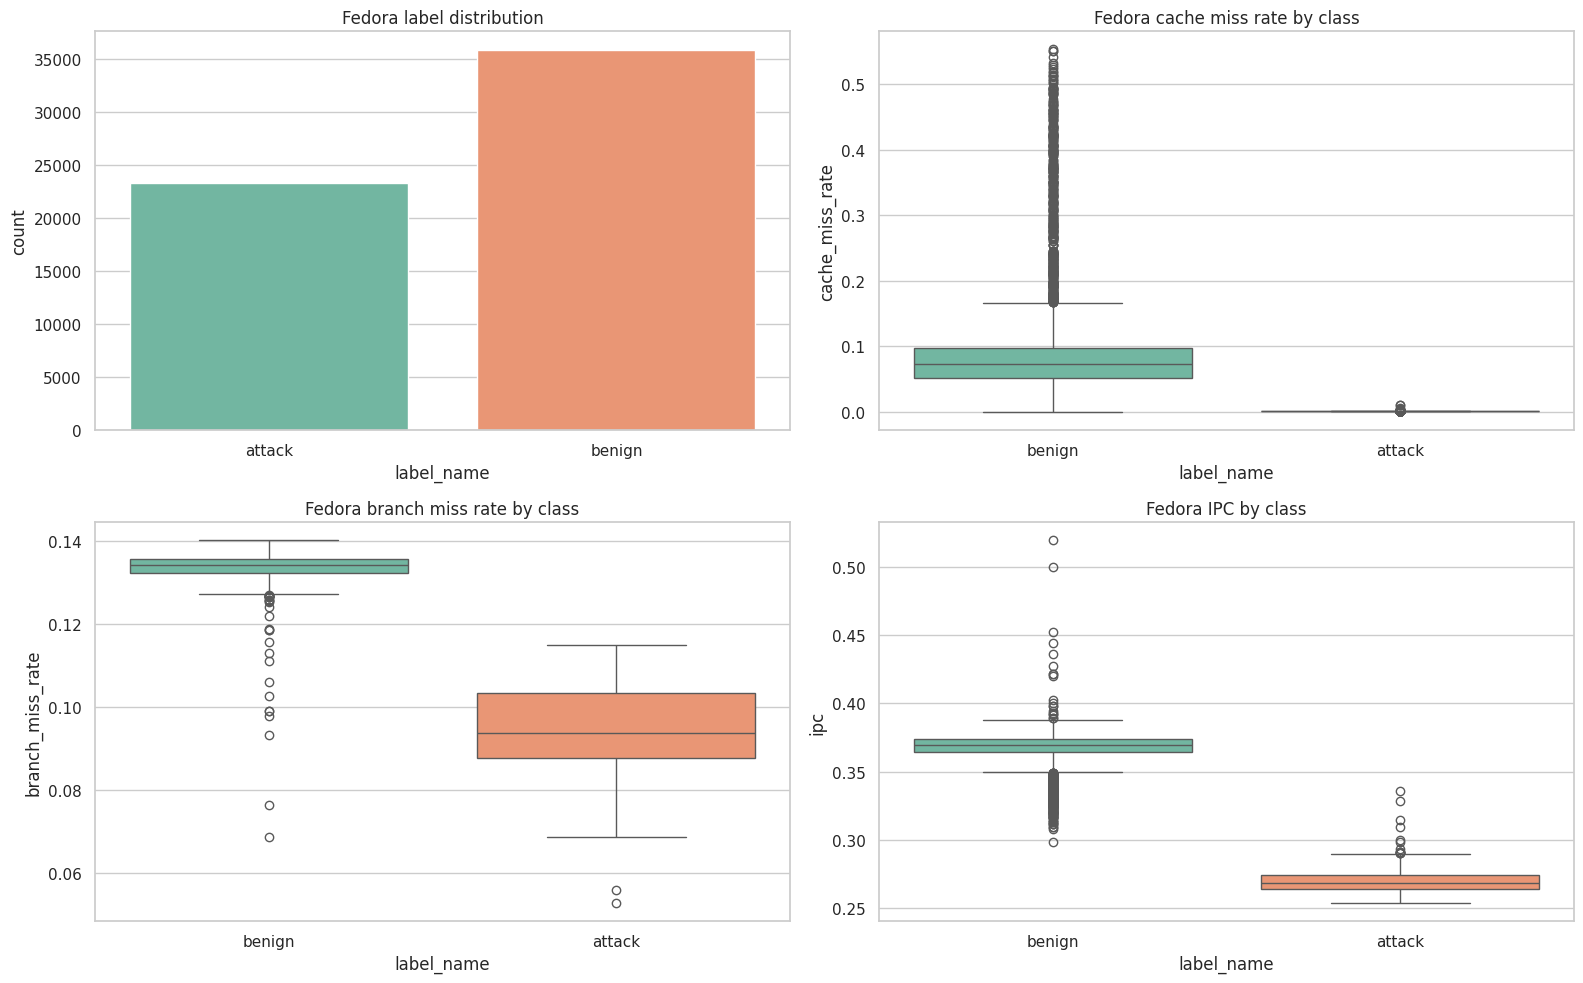

Saved figure: /home/ubuntu/SideChannelAI/results/fedora_eda_timelines.png


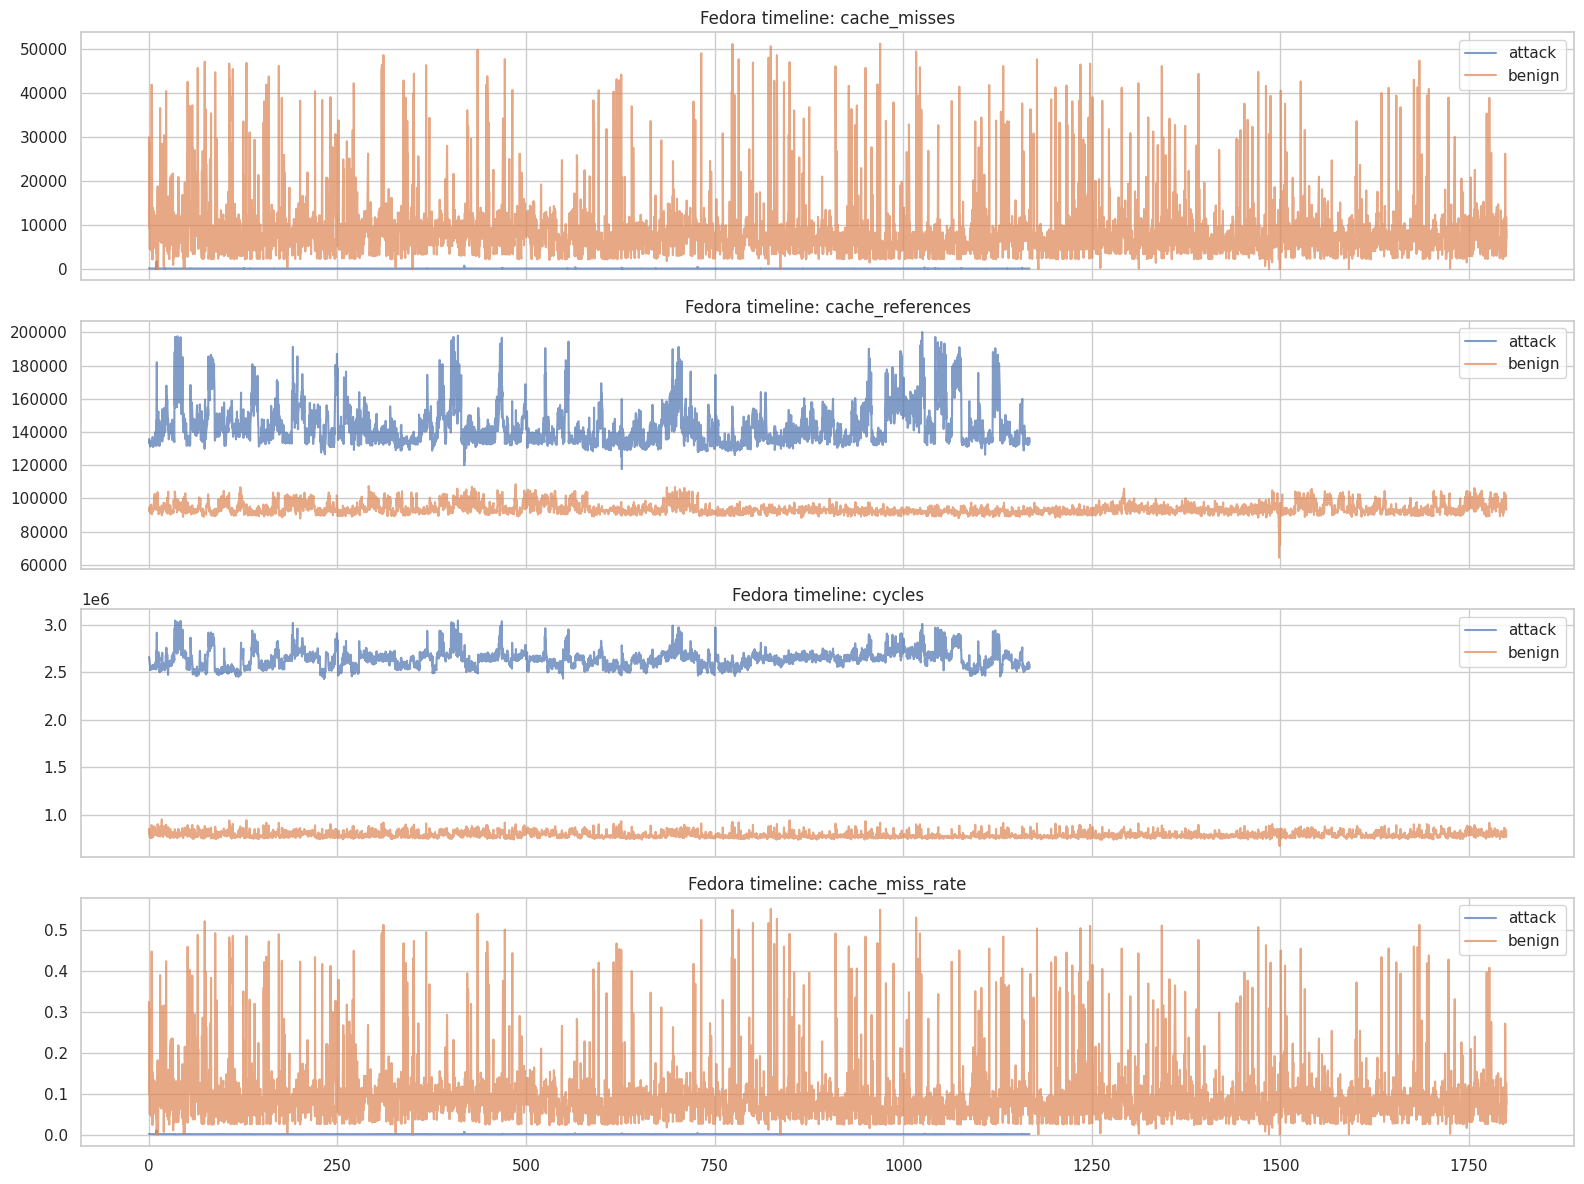

Saved figure: /home/ubuntu/SideChannelAI/results/fedora_correlation_heatmap.png


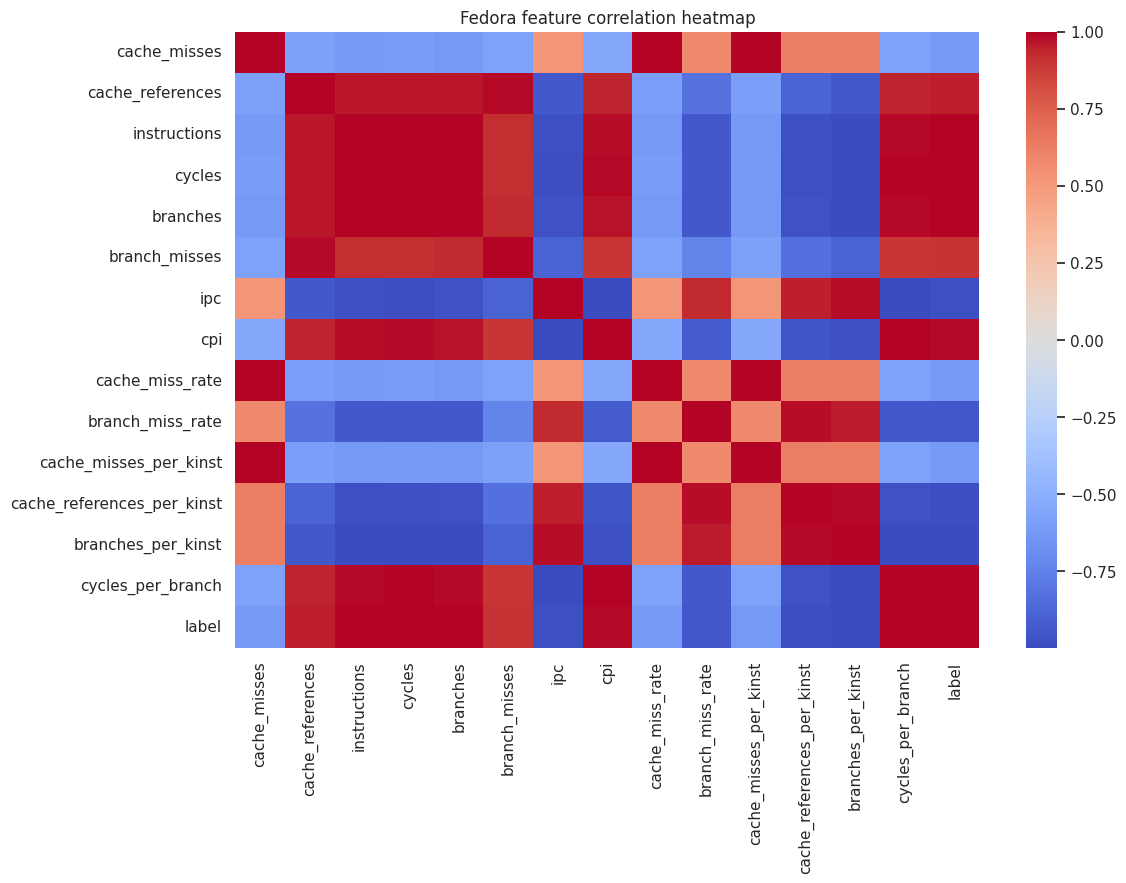

cache_misses                    cache_references            \
                   mean  median        std             mean    median   
label_name                                                              
attack         151.1080   149.0   111.3885      143797.3896  139866.0   
benign        8303.5613  7062.0  6320.4971       93686.9802   92807.0   

                       instructions                              cycles  \
                   std         mean    median         std          mean   
label_name                                                                
attack      12598.4238  710623.9296  704519.0  23339.1474  2.641518e+06   
benign       3065.3530  289882.8508  288996.0   9885.2434  7.877449e+05   

                                      branches                       \
               median         std         mean    median        std   
label_name                                                            
attack      2637196.0  92864.1326  124083.3315  122831.0  4576.3291   
benign       779393.0  30223.6522   60840.6577   60702.0  1919.9864   

           branch_misses                         ipc                     cpi  \
                    mean   median        std    mean  median     std    mean   
label_name                                                                     
attack        11895.7218  11525.0  1368.9033  0.2691  0.2682  0.0073  3.7181   
benign         8150.7654   8143.0   196.6666  0.3682  0.3691  0.0104  2.7182   

                           cache_miss_rate                 branch_miss_rate  \
            median     std            mean  median     std             mean   
label_name                                                                    
attack      3.7290  0.0992          0.0011  0.0011  0.0006           0.0957   
benign      2.7092  0.0797          0.0886  0.0736  0.0679           0.1340   

                           cache_misses_per_kinst                    \
            median     std                   mean   median      std   
label_name                                                            
attack      0.0937  0.0090                 0.2121   0.2106   0.0846   
benign      0.1342  0.0028                28.6707  24.0149  21.9404   

           cache_references_per_kinst                    branches_per_kinst  \
                                 mean    median      std               mean   
label_name                                                                    
attack                       202.1816  198.3724  13.5977           174.5927   
benign                       323.2921  324.3394   7.9020           209.8993   

                             cycles_per_branch                   
              median     std              mean   median     std  
label_name                                                       
attack      174.4276  0.7585           21.2964  21.3566  0.5819  
benign      210.0794  1.0696           12.9496  12.8930  0.3651

In [11]:
run_eda(fedora_df, "fedora")

## 7. Train/Test Splitting

To reduce temporal leakage, each class is split chronologically: the first 80% for training and the last 20% for testing.

In [12]:
META_COLUMNS = ["time_sec", "label", "label_name", "os_name", "source_file"]


def get_feature_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in df.columns if col not in META_COLUMNS]


def temporal_train_test_split(df: pd.DataFrame, test_ratio: float = 0.2):
    # We split chronologically inside each class instead of performing a fully
    # random split. This is more realistic for time-series-like HPC data.
    train_parts = []
    test_parts = []

    for label_name, subset in df.groupby("label_name"):
        subset = subset.sort_values("time_sec").reset_index(drop=True)
        split_idx = int(len(subset) * (1 - test_ratio))
        split_idx = max(split_idx, 1)
        train_parts.append(subset.iloc[:split_idx].copy())
        test_parts.append(subset.iloc[split_idx:].copy())

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    train_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return train_df, test_df

## 8. Classical ML Models

In [13]:
def evaluate_predictions(y_true, y_pred, y_score, model_name: str, os_name: str) -> dict:
    # Accuracy alone can be misleading in security detection, so we record
    # precision, recall, F1, and ROC-AUC wherever possible.
    metrics = {
        "os_name": os_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    return metrics


def plot_confusion(y_true, y_pred, title: str, filename: str):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "attack"])
    disp.plot(cmap="Blues")
    plt.title(title)
    save_current_figure(filename)
    plt.show()


def train_classical_models(df: pd.DataFrame, os_name: str):
    feature_cols = get_feature_columns(df)
    train_df, test_df = temporal_train_test_split(df)

    X_train = train_df[feature_cols]
    y_train = train_df["label"]
    X_test = test_df[feature_cols]
    y_test = test_df["label"]

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "SVM": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("svc", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=10000)),
            ]
        ),
    }

    trained = {}
    results = []
    reports = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            y_score = None

        metrics = evaluate_predictions(y_test, y_pred, y_score, model_name, os_name)
        results.append(metrics)
        trained[model_name] = model
        reports[model_name] = classification_report(
            y_test, y_pred, target_names=["benign", "attack"], zero_division=0
        )

        print(f"\n{os_name.title()} - {model_name}")
        print(reports[model_name])
        save_text(reports[model_name], f"{os_name}_{slugify(model_name)}_classification_report.txt")
        plot_confusion(
            y_test,
            y_pred,
            f"{os_name.title()} - {model_name}",
            f"{os_name}_{slugify(model_name)}_confusion_matrix.png",
        )

    results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False).reset_index(drop=True)
    return {
        "train_df": train_df,
        "test_df": test_df,
        "feature_cols": feature_cols,
        "models": trained,
        "metrics": results_df,
        "reports": reports,
    }


Ubuntu - Random Forest
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     14602
      attack       1.00      1.00      1.00     15503

    accuracy                           1.00     30105
   macro avg       1.00      1.00      1.00     30105
weighted avg       1.00      1.00      1.00     30105

Saved text report: /home/ubuntu/SideChannelAI/results/ubuntu_random_forest_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_random_forest_confusion_matrix.png


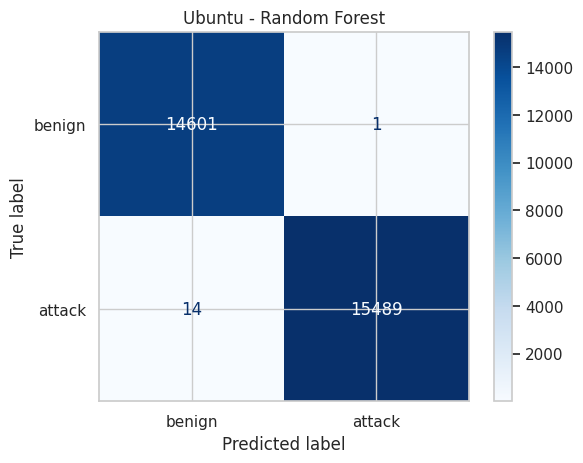


Ubuntu - SVM
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     14602
      attack       1.00      1.00      1.00     15503

    accuracy                           1.00     30105
   macro avg       1.00      1.00      1.00     30105
weighted avg       1.00      1.00      1.00     30105

Saved text report: /home/ubuntu/SideChannelAI/results/ubuntu_svm_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_svm_confusion_matrix.png


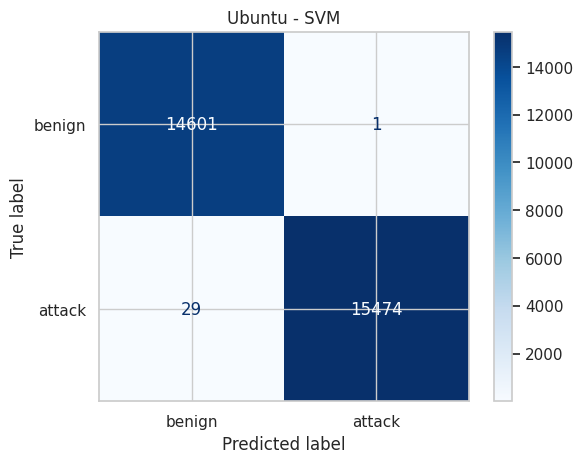

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,ubuntu,Random Forest,0.999502,0.999935,0.999097,0.999516,1.000000
1,ubuntu,SVM,0.999003,0.999935,0.998129,0.999032,0.998679


Saved table: /home/ubuntu/SideChannelAI/results/ubuntu_classical_metrics.csv


882

In [14]:
ubuntu_classical = train_classical_models(ubuntu_df, "ubuntu")
display(ubuntu_classical["metrics"])
save_dataframe(ubuntu_classical["metrics"], "ubuntu_classical_metrics.csv")
ubuntu_classical["metrics"].to_csv(ARTIFACTS_DIR / "ubuntu_classical_metrics.csv", index=False)
for model_name, model in ubuntu_classical["models"].items():
    safe_name = model_name.lower().replace(" ", "_")
    joblib.dump(model, ARTIFACTS_DIR / f"ubuntu_{safe_name}.joblib")

# Export feature metadata so the real-time monitor can rebuild exactly the
# same inference input order later on.
(ARTIFACTS_DIR / "ubuntu_feature_columns.json").write_text(
    json.dumps(ubuntu_classical["feature_cols"], indent=2),
    encoding="utf-8",
)


Fedora - Random Forest
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      7157
      attack       1.00      1.00      1.00      4648

    accuracy                           1.00     11805
   macro avg       1.00      1.00      1.00     11805
weighted avg       1.00      1.00      1.00     11805

Saved text report: /home/ubuntu/SideChannelAI/results/fedora_random_forest_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/fedora_random_forest_confusion_matrix.png


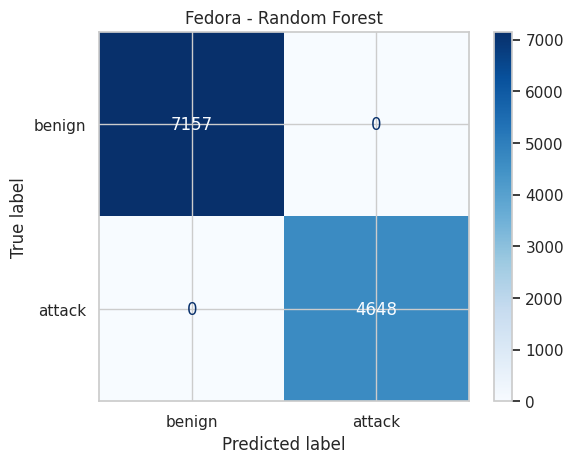


Fedora - SVM
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      7157
      attack       1.00      1.00      1.00      4648

    accuracy                           1.00     11805
   macro avg       1.00      1.00      1.00     11805
weighted avg       1.00      1.00      1.00     11805

Saved text report: /home/ubuntu/SideChannelAI/results/fedora_svm_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/fedora_svm_confusion_matrix.png


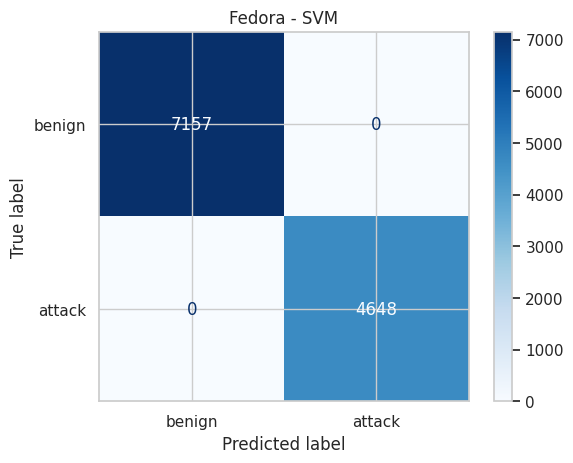

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,fedora,Random Forest,1.0,1.0,1.0,1.0,1.0
1,fedora,SVM,1.0,1.0,1.0,1.0,1.0


Saved table: /home/ubuntu/SideChannelAI/results/fedora_classical_metrics.csv


882

In [15]:
fedora_classical = train_classical_models(fedora_df, "fedora")
display(fedora_classical["metrics"])
save_dataframe(fedora_classical["metrics"], "fedora_classical_metrics.csv")
fedora_classical["metrics"].to_csv(ARTIFACTS_DIR / "fedora_classical_metrics.csv", index=False)
for model_name, model in fedora_classical["models"].items():
    safe_name = model_name.lower().replace(" ", "_")
    joblib.dump(model, ARTIFACTS_DIR / f"fedora_{safe_name}.joblib")

(ARTIFACTS_DIR / "fedora_feature_columns.json").write_text(
    json.dumps(fedora_classical["feature_cols"], indent=2),
    encoding="utf-8",
)

## 9. CNN-LSTM Hybrid

This section uses temporal sequences instead of independent rows. It is useful for capturing short-term counter dynamics that may distinguish benign execution from cache attack behavior.

In [17]:
SEQUENCE_FEATURES = RAW_EVENTS + RATIO_FEATURES
SEQUENCE_LENGTH = 20  # 20 x 50 ms = 1 second windows


def build_sequences(df: pd.DataFrame, feature_cols: list[str], sequence_length: int = SEQUENCE_LENGTH):
    # The CNN-LSTM consumes fixed-length sequences rather than single rows.
    # Each sequence becomes one training example with a binary label.
    sequences = []
    labels = []
    for label_name, subset in df.groupby("label_name"):
        subset = subset.sort_values("time_sec").reset_index(drop=True)
        values = subset[feature_cols].to_numpy(dtype=np.float32)
        label_value = int(subset["label"].iloc[0])
        if len(values) < sequence_length:
            continue
        for idx in range(len(values) - sequence_length + 1):
            sequences.append(values[idx : idx + sequence_length])
            labels.append(label_value)
    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int32)


def build_cnn_lstm(input_shape):
    # A compact hybrid model:
    # - Conv1D extracts local short-range signal patterns
    # - LSTM models temporal evolution over the window
    model = Sequential(
        [
            Conv1D(64, kernel_size=3, activation="relu", padding="same", input_shape=input_shape),
            BatchNormalization(),
            Conv1D(64, kernel_size=3, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
            LSTM(64),
            Dense(32, activation="relu"),
            Dropout(0.3),
            Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def train_cnn_lstm(df: pd.DataFrame, os_name: str):
    if not TF_AVAILABLE:
        raise ImportError(f"TensorFlow is not available: {TF_IMPORT_ERROR}")

    train_df, test_df = temporal_train_test_split(df)

    scaler = StandardScaler()
    train_scaled = train_df.copy()
    test_scaled = test_df.copy()

    train_scaled[SEQUENCE_FEATURES] = scaler.fit_transform(train_scaled[SEQUENCE_FEATURES])
    test_scaled[SEQUENCE_FEATURES] = scaler.transform(test_scaled[SEQUENCE_FEATURES])

    X_train_seq, y_train_seq = build_sequences(train_scaled, SEQUENCE_FEATURES)
    X_test_seq, y_test_seq = build_sequences(test_scaled, SEQUENCE_FEATURES)

    model = build_cnn_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_split=0.2,
        epochs=25,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1,
    )

    y_score = model.predict(X_test_seq, verbose=0).ravel()
    y_pred = (y_score >= 0.5).astype(int)

    metrics = evaluate_predictions(y_test_seq, y_pred, y_score, "CNN-LSTM", os_name)
    report_text = classification_report(
        y_test_seq, y_pred, target_names=["benign", "attack"], zero_division=0
    )

    print(f"\n{os_name.title()} - CNN-LSTM")
    print(report_text)
    save_text(report_text, f"{os_name}_cnn_lstm_classification_report.txt")
    plot_confusion(
        y_test_seq,
        y_pred,
        f"{os_name.title()} - CNN-LSTM",
        f"{os_name}_cnn_lstm_confusion_matrix.png",
    )

    history_df = pd.DataFrame(history.history)
    return {
        "model": model,
        "scaler": scaler,
        "metrics": pd.DataFrame([metrics]),
        "history": history_df,
        "test_labels": y_test_seq,
        "test_scores": y_score,
        "test_predictions": y_pred,
        "report_text": report_text,
    }

E0000 00:00:1777326719.934090    1009 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/25
753/753 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.9991 - auc: 1.0000 - loss: 0.0063 - precision: 0.9995 - recall: 0.9991 - val_accuracy: 0.9983 - val_auc: 0.0000e+00 - val_loss: 0.0036 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
753/753 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9998 - auc: 1.0000 - loss: 6.0661e-04 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 0.9974 - val_auc: 0.0000e+00 - val_loss: 0.0047 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
753/753 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9998 - auc: 1.0000 - loss: 6.1594e-04 - precision: 0.9998 - recall: 0.9999 - val_accuracy: 0.9975 - val_auc: 0.0000e+00 - val_loss: 0.0048 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
753/753 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9998 - auc: 1.0000 - loss: 4.9075e-04 - precision: 0.9997 - recall: 1.0000 - val_accuracy: 0.9975 - val_auc: 0.0000e+00 - val_loss: 0.0038 - val_precision: 

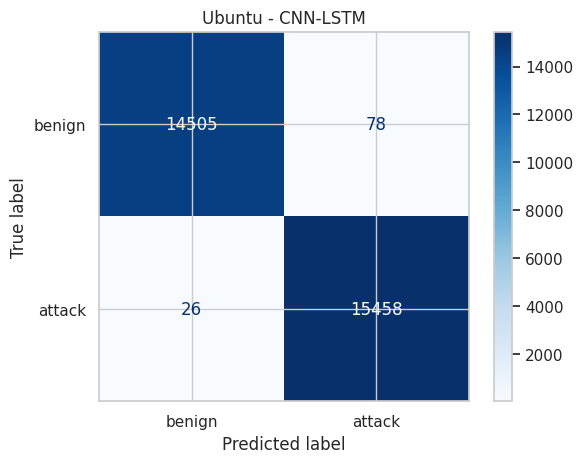

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,ubuntu,CNN-LSTM,0.996541,0.994979,0.998321,0.996647,0.999978


Saved table: /home/ubuntu/SideChannelAI/results/ubuntu_cnn_lstm_metrics.csv
Saved figure: /home/ubuntu/SideChannelAI/results/ubuntu_cnn_lstm_training_history.png


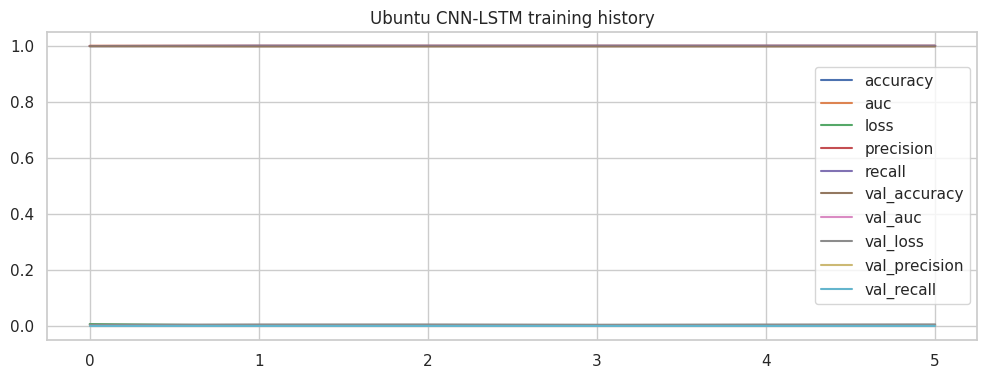

In [18]:
if TF_AVAILABLE:
    ubuntu_dl = train_cnn_lstm(ubuntu_df, "ubuntu")
    display(ubuntu_dl["metrics"])
    save_dataframe(ubuntu_dl["metrics"], "ubuntu_cnn_lstm_metrics.csv")
    ubuntu_dl["metrics"].to_csv(ARTIFACTS_DIR / "ubuntu_cnn_lstm_metrics.csv", index=False)
    ubuntu_dl["history"].plot(figsize=(12, 4), title="Ubuntu CNN-LSTM training history")
    save_current_figure("ubuntu_cnn_lstm_training_history.png")
    plt.show()
    ubuntu_dl["model"].save(ARTIFACTS_DIR / "ubuntu_cnn_lstm.keras")
    joblib.dump(ubuntu_dl["scaler"], ARTIFACTS_DIR / "ubuntu_cnn_lstm_scaler.joblib")
else:
    print("TensorFlow not available. Run the setup cell, then re-run this section.")

Epoch 1/25
295/295 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9965 - auc: 1.0000 - loss: 0.0153 - precision: 0.9958 - recall: 0.9972 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 2.4861e-05 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
295/295 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 2.7886e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 2.9334e-06 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
295/295 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.5708e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 6.9447e-07 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
295/295 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 8.2752e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 2.5108e-07 - va

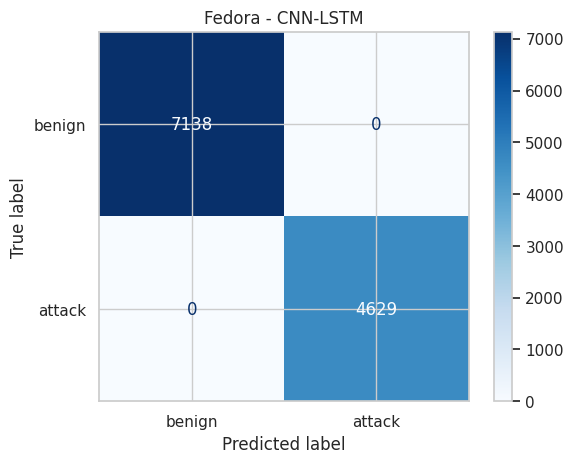

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,fedora,CNN-LSTM,1.0,1.0,1.0,1.0,1.0


Saved table: /home/ubuntu/SideChannelAI/results/fedora_cnn_lstm_metrics.csv
Saved figure: /home/ubuntu/SideChannelAI/results/fedora_cnn_lstm_training_history.png


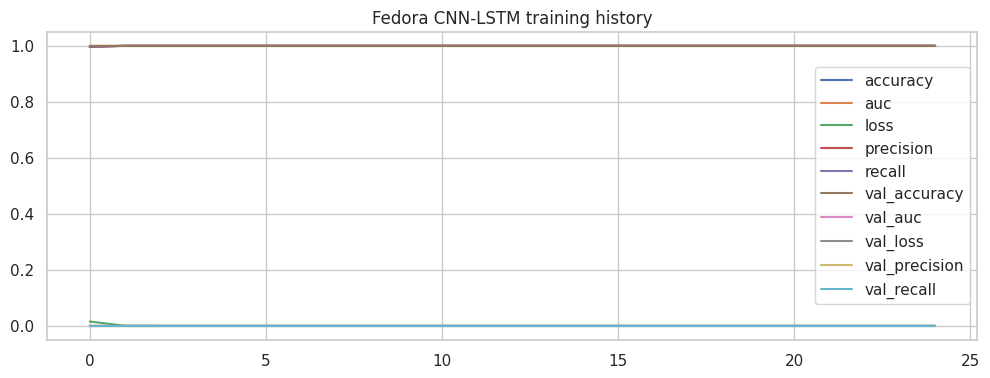

In [19]:
if TF_AVAILABLE:
    fedora_dl = train_cnn_lstm(fedora_df, "fedora")
    display(fedora_dl["metrics"])
    save_dataframe(fedora_dl["metrics"], "fedora_cnn_lstm_metrics.csv")
    fedora_dl["metrics"].to_csv(ARTIFACTS_DIR / "fedora_cnn_lstm_metrics.csv", index=False)
    fedora_dl["history"].plot(figsize=(12, 4), title="Fedora CNN-LSTM training history")
    save_current_figure("fedora_cnn_lstm_training_history.png")
    plt.show()
    fedora_dl["model"].save(ARTIFACTS_DIR / "fedora_cnn_lstm.keras")
    joblib.dump(fedora_dl["scaler"], ARTIFACTS_DIR / "fedora_cnn_lstm_scaler.joblib")
else:
    print("TensorFlow not available. Run the setup cell, then re-run this section.")

## 10. Per-OS Model Comparison

In [20]:
ubuntu_metrics = [ubuntu_classical["metrics"]]
fedora_metrics = [fedora_classical["metrics"]]

if TF_AVAILABLE and "ubuntu_dl" in globals():
    ubuntu_metrics.append(ubuntu_dl["metrics"])
if TF_AVAILABLE and "fedora_dl" in globals():
    fedora_metrics.append(fedora_dl["metrics"])

ubuntu_compare = pd.concat(ubuntu_metrics, ignore_index=True).sort_values("f1_score", ascending=False)
fedora_compare = pd.concat(fedora_metrics, ignore_index=True).sort_values("f1_score", ascending=False)

display(ubuntu_compare)
display(fedora_compare)

save_dataframe(ubuntu_compare, "ubuntu_model_comparison.csv")
save_dataframe(fedora_compare, "fedora_model_comparison.csv")

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,ubuntu,Random Forest,0.999502,0.999935,0.999097,0.999516,1.000000
1,ubuntu,SVM,0.999003,0.999935,0.998129,0.999032,0.998679
2,ubuntu,CNN-LSTM,0.996541,0.994979,0.998321,0.996647,0.999978


,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,fedora,Random Forest,1.0,1.0,1.0,1.0,1.0
1,fedora,SVM,1.0,1.0,1.0,1.0,1.0
2,fedora,CNN-LSTM,1.0,1.0,1.0,1.0,1.0


Saved table: /home/ubuntu/SideChannelAI/results/ubuntu_model_comparison.csv
Saved table: /home/ubuntu/SideChannelAI/results/fedora_model_comparison.csv


Saved figure: /home/ubuntu/SideChannelAI/results/per_os_model_comparison_f1.png


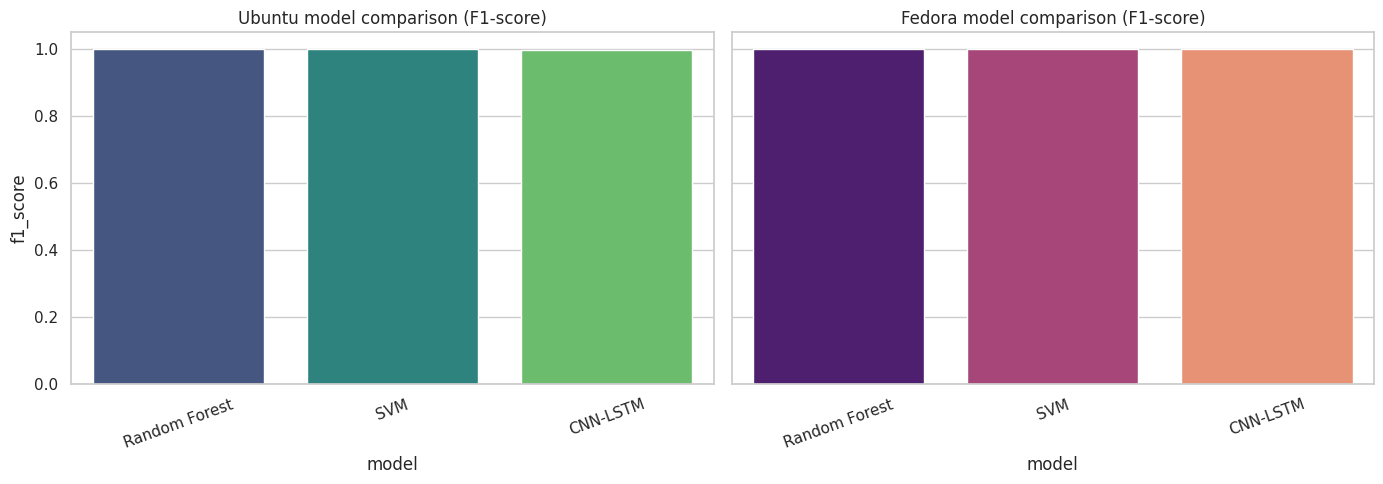

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.barplot(data=ubuntu_compare, x="model", y="f1_score", ax=axes[0], palette="viridis")
axes[0].set_title("Ubuntu model comparison (F1-score)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=fedora_compare, x="model", y="f1_score", ax=axes[1], palette="magma")
axes[1].set_title("Fedora model comparison (F1-score)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_current_figure("per_os_model_comparison_f1.png")
plt.show()

## 11. Cross-OS Comparison

This table helps compare how the same model family behaves across Ubuntu and Fedora.

In [22]:
overall_compare = pd.concat([ubuntu_compare, fedora_compare], ignore_index=True)
display(overall_compare.sort_values(["model", "f1_score"], ascending=[True, False]))

overall_compare.to_csv(ARTIFACTS_DIR / "overall_model_comparison.csv", index=False)
save_dataframe(overall_compare, "overall_model_comparison.csv")

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
5,fedora,CNN-LSTM,1.000000,1.000000,1.000000,1.000000,1.000000
2,ubuntu,CNN-LSTM,0.996541,0.994979,0.998321,0.996647,0.999978
3,fedora,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
0,ubuntu,Random Forest,0.999502,0.999935,0.999097,0.999516,1.000000
4,fedora,SVM,1.000000,1.000000,1.000000,1.000000,1.000000
1,ubuntu,SVM,0.999003,0.999935,0.998129,0.999032,0.998679


Saved table: /home/ubuntu/SideChannelAI/results/overall_model_comparison.csv


Saved figure: /home/ubuntu/SideChannelAI/results/cross_os_model_comparison_f1.png


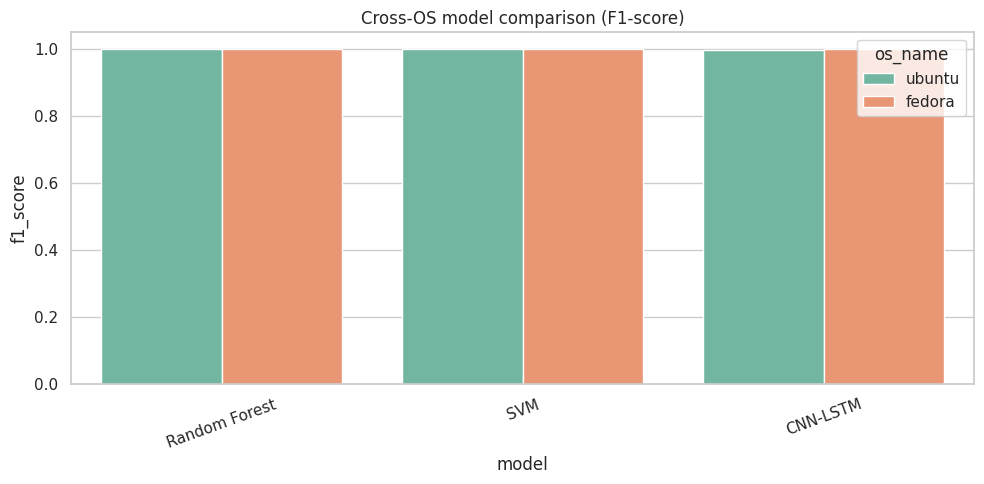

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=overall_compare, x="model", y="f1_score", hue="os_name", palette="Set2")
plt.title("Cross-OS model comparison (F1-score)")
plt.xticks(rotation=20)
plt.tight_layout()
save_current_figure("cross_os_model_comparison_f1.png")
plt.show()

## 12. Optional Cross-OS Generalization Test

This experiment is useful for your portability objective:

- Train on Ubuntu
- Test on Fedora

It evaluates whether a model trained on one Linux distribution transfers to another without retraining.

              precision    recall  f1-score   support

      benign       1.00      0.99      0.99     35783
      attack       0.98      1.00      0.99     23237

    accuracy                           0.99     59020
   macro avg       0.99      0.99      0.99     59020
weighted avg       0.99      0.99      0.99     59020

Saved text report: /home/ubuntu/SideChannelAI/results/cross_os_random_forest_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/cross_os_random_forest_confusion_matrix.png


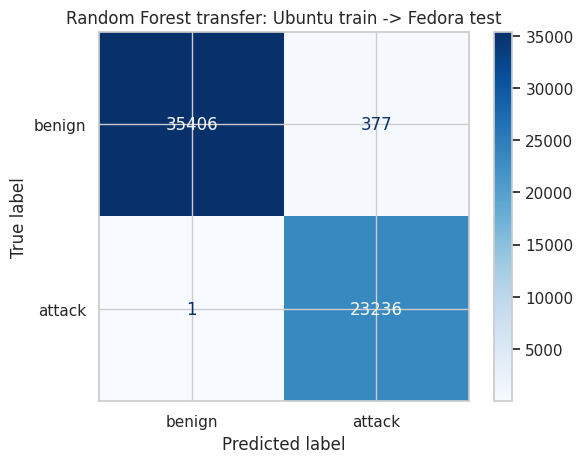

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     35783
      attack       1.00      1.00      1.00     23237

    accuracy                           1.00     59020
   macro avg       1.00      1.00      1.00     59020
weighted avg       1.00      1.00      1.00     59020

Saved text report: /home/ubuntu/SideChannelAI/results/cross_os_svm_classification_report.txt
Saved figure: /home/ubuntu/SideChannelAI/results/cross_os_svm_confusion_matrix.png


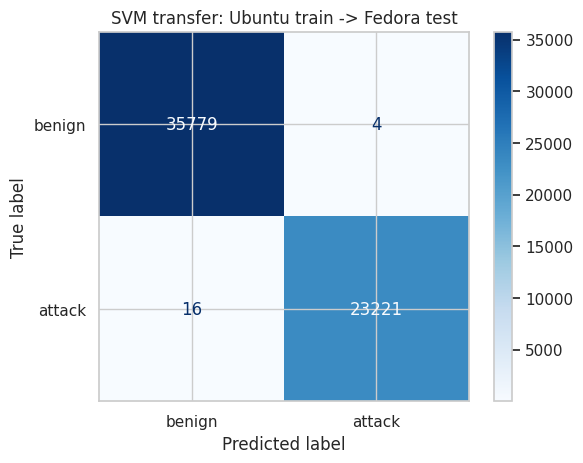

,os_name,model,accuracy,precision,recall,f1_score,roc_auc
0,cross_os,Random Forest (Ubuntu->Fedora),0.993595,0.984034,0.999957,0.991932,0.999921
1,cross_os,SVM (Ubuntu->Fedora),0.999661,0.999828,0.999311,0.999570,0.999984


Saved table: /home/ubuntu/SideChannelAI/results/ubuntu_to_fedora_transfer_metrics.csv


In [24]:
def cross_os_transfer_train_test(train_df: pd.DataFrame, test_df: pd.DataFrame, model_name: str = "Random Forest"):
    feature_cols = get_feature_columns(train_df)
    X_train = train_df[feature_cols]
    y_train = train_df["label"]
    X_test = test_df[feature_cols]
    y_test = test_df["label"]

    if model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    elif model_name == "SVM":
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("svc", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=10000)),
            ]
        )
    else:
        raise ValueError("model_name must be 'Random Forest' or 'SVM'")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    metrics = evaluate_predictions(y_test, y_pred, y_score, f"{model_name} (Ubuntu->Fedora)", "cross_os")
    report_text = classification_report(y_test, y_pred, target_names=["benign", "attack"], zero_division=0)
    print(report_text)
    save_text(report_text, f"cross_os_{slugify(model_name)}_classification_report.txt")
    plot_confusion(
        y_test,
        y_pred,
        f"{model_name} transfer: Ubuntu train -> Fedora test",
        f"cross_os_{slugify(model_name)}_confusion_matrix.png",
    )
    return metrics


ubuntu_full = ubuntu_df.sort_values(["label_name", "time_sec"]).reset_index(drop=True)
fedora_full = fedora_df.sort_values(["label_name", "time_sec"]).reset_index(drop=True)

transfer_results = pd.DataFrame(
    [
        cross_os_transfer_train_test(ubuntu_full, fedora_full, "Random Forest"),
        cross_os_transfer_train_test(ubuntu_full, fedora_full, "SVM"),
    ]
)

display(transfer_results)
transfer_results.to_csv(ARTIFACTS_DIR / "ubuntu_to_fedora_transfer_metrics.csv", index=False)
save_dataframe(transfer_results, "ubuntu_to_fedora_transfer_metrics.csv")

## 13. Runtime Deployment Preparation

The next code cell writes a compact metadata file describing the best available classical model per operating system.
This metadata is meant for the real-time monitor script that you can run separately on AWS.

In [25]:
def pick_best_classical_model(metrics_df: pd.DataFrame) -> dict:
    row = metrics_df.sort_values(["f1_score", "accuracy"], ascending=False).iloc[0]
    return {
        "model": row["model"],
        "accuracy": float(row["accuracy"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "roc_auc": None if pd.isna(row["roc_auc"]) else float(row["roc_auc"]),
    }


runtime_manifest = {
    "ubuntu_best_classical_model": pick_best_classical_model(ubuntu_classical["metrics"]),
    "fedora_best_classical_model": pick_best_classical_model(fedora_classical["metrics"]),
    "raw_events": RAW_EVENTS,
    "ratio_features": RATIO_FEATURES,
    "sequence_features": SEQUENCE_FEATURES,
}

(RESULTS_DIR / "runtime_manifest.json").write_text(json.dumps(runtime_manifest, indent=2), encoding="utf-8")
print(json.dumps(runtime_manifest, indent=2))
print(f"Saved runtime manifest to: {RESULTS_DIR / 'runtime_manifest.json'}")

{
  "ubuntu_best_classical_model": {
    "model": "Random Forest",
    "accuracy": 0.9995017438963627,
    "precision": 0.9999354422207876,
    "recall": 0.9990969489776172,
    "f1_score": 0.9995160197463944,
    "roc_auc": 0.9999998078408072
  },
  "fedora_best_classical_model": {
    "model": "Random Forest",
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1_score": 1.0,
    "roc_auc": 1.0
  },
  "raw_events": [
    "cache_misses",
    "cache_references",
    "instructions",
    "cycles",
    "branches",
    "branch_misses"
  ],
  "ratio_features": [
    "ipc",
    "cpi",
    "cache_miss_rate",
    "branch_miss_rate",
    "cache_misses_per_kinst",
    "cache_references_per_kinst",
    "branches_per_kinst",
    "cycles_per_branch"
  ],
  "sequence_features": [
    "cache_misses",
    "cache_references",
    "instructions",
    "cycles",
    "branches",
    "branch_misses",
    "ipc",
    "cpi",
    "cache_miss_rate",
    "branch_miss_rate",
    "cache_misses_per_k

## 14. Final Notes

Recommended reporting flow for your project:

1. Show the raw counter collection methodology.
2. Explain the Ubuntu/Fedora formatting mismatch and your hybrid ingestion engine.
3. Present EDA evidence that attack traces shift cache-related behavior.
4. Compare classical and deep models separately for Ubuntu and Fedora.
5. Use the cross-OS section to discuss portability strengths and limitations.
6. Emphasize F1-score, recall, and false-positive behavior, not only accuracy.

Outputs saved to `results/`:

- EDA plots
- Confusion matrices
- Training history plots
- Per-OS and cross-OS comparison charts
- Summary metric CSV files
- Text classification reports
- Runtime manifest for live deployment

Model artifacts saved to `artifacts/`:

- Classical model `.joblib` files
- CNN-LSTM `.keras` models and scalers when TensorFlow is available